# Basic GOAD Usage

This notebook demonstrates how to access basic GOAD (Geometric Optics Approximation with Diffraction) functionality in Python.

## Outline

- Import modules
- Set particle geometry
- Configure settings
- Create and solve a problem with multiple orientations
- Access results and plot some stuff


### 1. Imports


In [48]:
# Import modules
import goad_py as goad
import numpy as np
import matplotlib.pyplot as plt
import os

### 2. Load Geometry File

- Set some path config so that we can access the example geometries in the project root
- Typically, you would configure the path to wherever you keep your geometry files
- Or, just ignore this part if your geometry files are in the project directory


In [49]:
# Some jargon to get access to the example geometries
current_dir = os.path.dirname(os.path.abspath(os.getcwd()))
geom_path = os.path.join(current_dir, "..", "examples", "data", "hex.obj")
geom_path = os.path.abspath(geom_path)

print(f"Geometry file: {geom_path}")

Geometry file: /Users/ixguard/Documents/work/rust/goad/examples/data/hex.obj


### 3. Configure Simulation Settings

- You can set most of the job settings here


In [50]:
# Create settings
settings = goad.Settings(
    geom_path=geom_path,
    wavelength=0.532,  # wavelength in particle units
    particle_refr_index_re=1.31,  # refr. index real part
    particle_refr_index_im=0.0,  # refr. index imaginary part
    medium_refr_index_re=1.0,  # surrounding medium refr. index real part
    medium_refr_index_im=0.0,  # surrounding medium refr. index imaginary part
    orientation=goad.create_uniform_orientation(100),  # 100 random orientations
    beam_power_threshold=0.005,  # power threshold before beam truncation
    cutoff=0.9999,  # total power cutoff before simulation ends
    max_rec=10,  # maximum number of beam recursions before truncation
    max_tir=10,  # maximum number of beam total internal reflections before truncation
)

### 4. Create and Solve the MultiProblem

- Pretty straightforward...
- A multiproblem averages the scattering over multiple orientations, which is equivalent to illumination from multiple directions
- Solve the problem (multithreaded) with `py_solve()`
- 100 orientations for the basic hexagonal column shape takes a few seconds on a laptop


In [51]:
# Create MultiProblem
multi_problem = goad.MultiProblem(settings)
print(f"Number of orientations: {multi_problem.num_orientations}")

# Solve the problem
multi_problem.py_solve()
print("Done.")

Number of orientations: 100
Done.


### 5. Results and Visualisation

- Most useful output information is accessible via `results`:
- `results.scat_cross`: scattering cross section
- `results.ext_cross`: extinction cross section
- `results.albedo`: single scattering albedo
- `results.asymmetry`: asymmetry parameter
- `results.mueller`: 2d mueller matrix
- `results.mueller_1d`: 1d mueller matrix
- `results.bins`: 2d (`theta`, `phi`) bin pairs
- `results.bins_1d`: 1d `theta` values


In [52]:
# Print results
results = multi_problem.results

print("Integrated Scattering Parameters:")
print(f"  Scattering cross-section: {results.scat_cross:.6f}")
print(f"  Extinction cross-section: {results.ext_cross:.6f}")
print(f"  Absorption cross-section: {results.ext_cross - results.scat_cross:.6f}")
print(f"  Single scattering albedo: {results.albedo:.6f}")
print(f"  Asymmetry parameter: {results.asymmetry:.6f}")

Integrated Scattering Parameters:
  Scattering cross-section: 203.146271
  Extinction cross-section: 203.146271
  Absorption cross-section: 0.000000
  Single scattering albedo: 1.000000
  Asymmetry parameter: 0.755972


Number of angular bins: 154
Angular range: 0.0° to 180.0°


/var/folders/gm/hm74nwpd4nsfxdphjf3hw96h0000gn/T/ipykernel_65650/3025175287.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


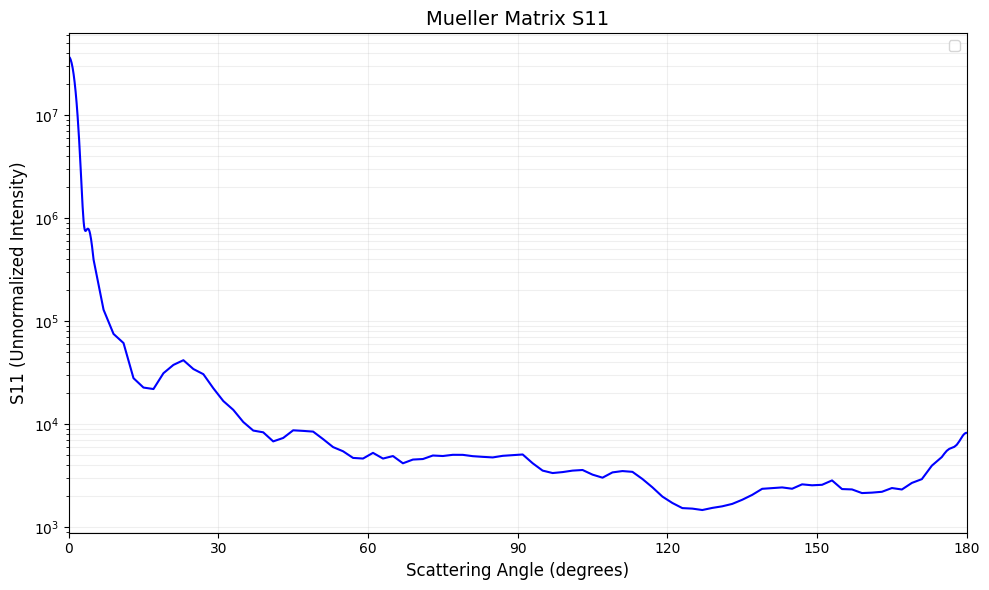

In [53]:
# Extract S11 element from 1D Mueller matrix
mueller_1d = results.mueller_1d
bins_1d = results.bins_1d

# S11 is the first element of the Mueller matrix
s11 = [row[0] for row in mueller_1d]  # Filter out zero or negative values for log scale
angles = bins_1d[: len(s11)]  # Match angles to filtered S11 values

print(f"Number of angular bins: {len(angles)}")
print(f"Angular range: {angles[0]:.1f}° to {angles[-1]:.1f}°")

# Plot S11 element
plt.figure(figsize=(10, 6))
plt.semilogy(angles, s11, "b-", linewidth=1.5)
plt.xlabel("Scattering Angle (degrees)", fontsize=12)
plt.ylabel("S11 (Unnormalized Intensity)", fontsize=12)
plt.title("Mueller Matrix S11", fontsize=14)
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.xlim(0, 180)
plt.xticks(np.arange(0, 181, 30))

plt.legend()
plt.tight_layout()
plt.show()